# Geneformer Noise Scaling on PBMC — fine-tuned vs from-scratch

Loads MI for the `protein_counts` signal from two arms:
1. **finetune** — new sweep at `data/other/geneformer_noise_scaling/{size}/{quality}/MI/{seed}/Y_protein_counts/lmi_mutual_information.txt` (this notebook's companion script).
2. **from_scratch** — the existing PBMC Geneformer runs at `data/PBMC/{size}/{quality}/results/Geneformer/model/MI/{seed}/Y_protein_counts_{quality}_geneformer/lmi_mutual_information.txt`.

Plots MI vs quality with size-scaled markers (viridis, log-norm by size), formatted to match `2026-04-14_15-25_collect_and_plot_mi_scaling.ipynb`.

In [1]:
import os
from itertools import product
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm.auto import tqdm

DATA_ROOT = Path('/home/igor/noise_scaling/data')
FINETUNE_ROOT = DATA_ROOT / 'other' / 'geneformer_noise_scaling'
DATASET = 'PBMC'
SIGNAL = 'protein_counts'

SIZES = [100, 215, 464, 1000, 2154, 4641, 10000, 21544, 46415, 100000]
QUALITIES = [0.0012346, 0.0025982, 0.0054682, 0.0115083, 0.02422,
             0.050973, 0.1072766, 0.225772, 0.4751547, 1.0]
FINETUNE_SEEDS = [42]
FROM_SCRATCH_SEEDS = [42, 1404, 2303, 2701]

def _read_mi(p):
    try:
        with open(p) as f:
            return float(f.read().strip())
    except Exception:
        return np.nan

/home/igor/miniconda3/envs/modeling/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1) New finetune sweep
rows = []
for sz, q, sd in product(SIZES, QUALITIES, FINETUNE_SEEDS):
    p = FINETUNE_ROOT / str(sz) / str(q) / 'MI' / str(sd) / 'Y_protein_counts' / 'lmi_mutual_information.txt'
    rows.append({'size': sz, 'quality': q, 'seed': sd, 'source': 'finetune', 'path': str(p)})
df_ft = pd.DataFrame(rows)
with ThreadPoolExecutor(max_workers=128) as pool:
    df_ft['exists'] = list(pool.map(os.path.exists, df_ft['path']))
df_ft = df_ft[df_ft['exists']].copy()
with ThreadPoolExecutor(max_workers=128) as pool:
    df_ft['mi_value'] = list(pool.map(_read_mi, df_ft['path']))
print(f'finetune: loaded {len(df_ft)} / {len(SIZES) * len(QUALITIES) * len(FINETUNE_SEEDS)}')
df_ft.head()

finetune: loaded 1 / 100


,size,quality,seed,source,path,exists,mi_value
9,100,1.0,42,finetune,/home/igor/noise_scaling/data/other/geneformer...,True,3.77905


In [3]:
# 2) Existing PBMC/Geneformer (from-scratch) results — same protein_counts signal
rows = []
for sz, q, sd in product(SIZES, QUALITIES, FROM_SCRATCH_SEEDS):
    stem = f'Y_{SIGNAL}_{q}_geneformer'
    p = DATA_ROOT / DATASET / str(sz) / str(q) / 'results' / 'Geneformer' / 'model' / 'MI' / str(sd) / stem / 'lmi_mutual_information.txt'
    rows.append({'size': sz, 'quality': q, 'seed': sd, 'source': 'from_scratch', 'path': str(p)})
df_fs = pd.DataFrame(rows)
with ThreadPoolExecutor(max_workers=128) as pool:
    df_fs['exists'] = list(pool.map(os.path.exists, df_fs['path']))
df_fs = df_fs[df_fs['exists']].copy()
with ThreadPoolExecutor(max_workers=128) as pool:
    df_fs['mi_value'] = list(pool.map(_read_mi, df_fs['path']))
print(f'from_scratch: loaded {len(df_fs)} / {len(SIZES) * len(QUALITIES) * len(FROM_SCRATCH_SEEDS)}')
df_fs.head()

from_scratch: loaded 396 / 400


,size,quality,seed,source,path,exists,mi_value
0,100,0.001235,42,from_scratch,/home/igor/noise_scaling/data/PBMC/100/0.00123...,True,0.65307
1,100,0.001235,1404,from_scratch,/home/igor/noise_scaling/data/PBMC/100/0.00123...,True,0.67420
2,100,0.001235,2303,from_scratch,/home/igor/noise_scaling/data/PBMC/100/0.00123...,True,0.67208
3,100,0.001235,2701,from_scratch,/home/igor/noise_scaling/data/PBMC/100/0.00123...,True,0.73480
4,100,0.002598,42,from_scratch,/home/igor/noise_scaling/data/PBMC/100/0.00259...,True,0.99662


In [4]:
df = pd.concat([df_ft, df_fs], ignore_index=True)[['source', 'size', 'quality', 'seed', 'mi_value']]
df = df.sort_values(['source', 'size', 'quality', 'seed']).reset_index(drop=True)
print(f'total rows: {len(df)}  (finetune: {len(df_ft)}, from_scratch: {len(df_fs)})')

# Coverage matrix (per source, count of seeds present per cell)
for src in ['finetune', 'from_scratch']:
    sub = df[df['source'] == src]
    grid = sub.groupby(['size', 'quality'])['seed'].nunique().unstack('quality', fill_value=0)
    print(f'\n{src}: seeds present per (size, quality)  (total {len(sub)} rows)')
    if not grid.empty:
        grid.columns = [f'{q:.4g}' for q in grid.columns]
        display(grid)

total rows: 397  (finetune: 1, from_scratch: 396)

finetune: seeds present per (size, quality)  (total 1 rows)


,1
size,
100,1



from_scratch: seeds present per (size, quality)  (total 396 rows)


,0.001235,0.002598,0.005468,0.01151,0.02422,0.05097,0.1073,0.2258,0.4752,1
size,,,,,,,,,,
100,4,4,4,4,4,4,4,4,4,4
215,4,4,4,4,4,4,4,4,4,4
464,4,4,4,4,4,3,4,4,4,4
1000,4,4,4,4,4,4,3,4,4,4
2154,4,4,4,4,4,4,4,4,4,3
4641,4,4,4,4,4,4,4,4,4,4
10000,4,4,4,4,4,4,4,4,4,4
21544,4,4,4,4,4,4,4,4,4,4
46415,4,4,4,4,4,4,4,4,4,4


In [5]:
def _fmt_size(sz):
    if sz >= 1_000_000:
        return f'{sz/1_000_000:.0f}M' if sz % 1_000_000 == 0 else f'{sz/1_000_000:.1f}M'
    if sz >= 1_000:
        return f'{sz/1_000:.0f}k' if sz % 1_000 == 0 else f'{sz/1_000:.1f}k'
    return str(sz)

MARKER_SIZE = 5  # fixed marker size for every point (no scaling by # cells)

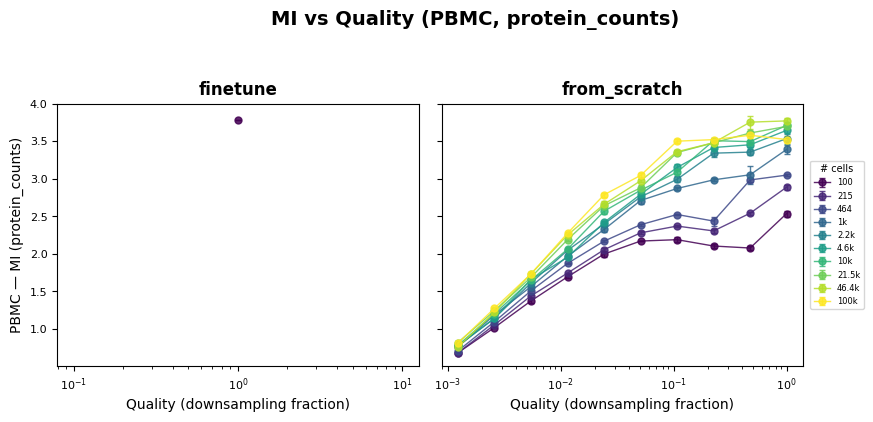

In [6]:
def plot_mi_vs_quality(df, title='MI vs Quality (PBMC, protein_counts)'):
    """One column per source. Lines per size, colored by viridis(LogNorm(size))."""
    sources = [s for s in ['finetune', 'from_scratch'] if s in df['source'].unique()]
    n_cols = len(sources)
    fig, axes = plt.subplots(1, n_cols,
                             figsize=(4 * n_cols + 1.6, 3.5 + 0.8),
                             squeeze=False, sharey=True)
    cmap = plt.cm.viridis
    sizes_all = sorted(df['size'].unique())
    norm = mcolors.LogNorm(vmin=min(sizes_all), vmax=max(sizes_all))

    for j, src in enumerate(sources):
        ax = axes[0, j]
        sub = df[df['source'] == src]
        if sub.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='gray', fontsize=10)
            ax.set_xscale('log')
            continue
        for sz in sorted(sub['size'].unique()):
            color = cmap(norm(sz))
            sz_df = sub[sub['size'] == sz]
            agg = sz_df.groupby('quality')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
            agg = agg.sort_values('quality')
            agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
            ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                        marker='o', markersize=MARKER_SIZE, linewidth=1, capsize=2,
                        color=color, alpha=0.85, label=_fmt_size(sz))
        ax.set_xscale('log')
        ax.set_xlabel('Quality (downsampling fraction)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'PBMC — MI ({SIGNAL})', fontsize=10)
        ax.set_title(src, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=8)

    last_ax = axes[0, -1]
    handles, labels = last_ax.get_legend_handles_labels()
    if handles:
        last_ax.legend(handles, labels, title='# cells', fontsize=6,
                       title_fontsize=7, loc='center left',
                       bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                       frameon=True, framealpha=0.8)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 0.92, 0.93])
    return fig

_ = plot_mi_vs_quality(df)
plt.show()

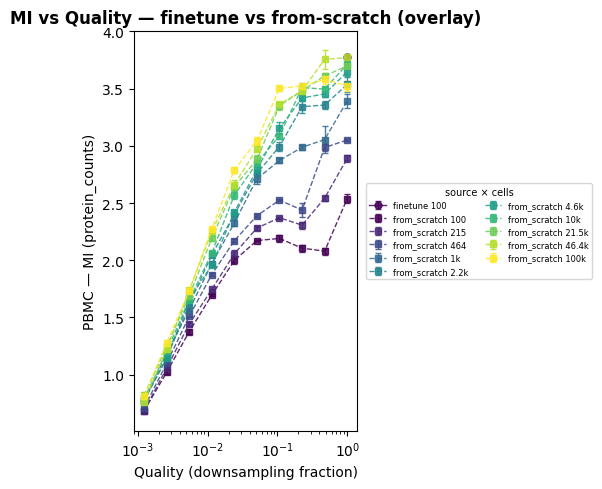

In [7]:
def plot_overlay(df, title='MI vs Quality — finetune vs from-scratch (overlay)'):
    """Single panel: dashed = from_scratch, solid = finetune, color = size."""
    fig, ax = plt.subplots(figsize=(7, 5))
    cmap = plt.cm.viridis
    sizes_all = sorted(df['size'].unique())
    norm = mcolors.LogNorm(vmin=min(sizes_all), vmax=max(sizes_all))

    style = {'finetune': dict(linestyle='-',  marker='o'),
             'from_scratch': dict(linestyle='--', marker='s')}
    for sz in sizes_all:
        color = cmap(norm(sz))
        for src in ['finetune', 'from_scratch']:
            sub = df[(df['source'] == src) & (df['size'] == sz)]
            if sub.empty:
                continue
            agg = sub.groupby('quality')['mi_value'].agg(['mean', 'std', 'count']).reset_index()
            agg = agg.sort_values('quality')
            agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
            ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                        markersize=MARKER_SIZE, linewidth=1, capsize=2, color=color,
                        alpha=0.85, **style[src],
                        label=f'{src} {_fmt_size(sz)}')
    ax.set_xscale('log')
    ax.set_xlabel('Quality (downsampling fraction)', fontsize=10)
    ax.set_ylabel(f'PBMC — MI ({SIGNAL})', fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=6, title='source × cells', title_fontsize=7,
              loc='center left', bbox_to_anchor=(1.02, 0.5),
              ncol=2, frameon=True, framealpha=0.8)
    fig.tight_layout(rect=[0, 0, 0.78, 1])
    return fig

_ = plot_overlay(df)
plt.show()

In [8]:
# Optional: fit the noise-scaling model I(u) = I_max - 0.5 * log2((1 + u/u_bar)/(u/u_bar + 2^(-2*I_max)))
# per (source, size). Same fit as in 2026-04-14_15-25_collect_and_plot_mi_scaling.ipynb.
from lmfit import Model
import warnings

def info_scaling(u, u_bar, I_max):
    u = np.asarray(u, dtype=float)
    eps = 1e-12
    u_bar_safe = max(float(u_bar), eps)
    r = u / u_bar_safe
    num = 1 + r
    den = r + 2 ** (-2 * float(I_max))
    den = np.where(den == 0, eps, den)
    return float(I_max) - 0.5 * np.log2(np.clip(num / den, eps, None))

def fit_one(u_vals, mi_vals):
    m = Model(info_scaling)
    p = m.make_params(u_bar=0.05, I_max=1.0)
    p['u_bar'].min = 1e-12
    p['I_max'].min = 0
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            res = m.fit(mi_vals, p, u=u_vals)
        return {'u_bar': res.params['u_bar'].value,
                'I_max': res.params['I_max'].value, 'success': True}
    except Exception:
        return {'u_bar': np.nan, 'I_max': np.nan, 'success': False}

fits = []
for (src, sz), grp in df.groupby(['source', 'size']):
    agg = grp.groupby('quality')['mi_value'].mean().reset_index().sort_values('quality')
    if len(agg) < 3:
        continue
    res = fit_one(agg['quality'].values, agg['mi_value'].values)
    fits.append({'source': src, 'size': sz, **res})
df_fits = pd.DataFrame(fits)
df_fits.head(20)

,source,size,u_bar,I_max,success
0,from_scratch,100,0.016296,2.295667,True
1,from_scratch,215,0.027654,2.605766,True
2,from_scratch,464,0.037640,2.853761,True
3,from_scratch,1000,0.057473,3.231384,True
4,from_scratch,2154,0.086508,3.518321,True
5,from_scratch,4641,0.107090,3.658783,True
6,from_scratch,10000,0.104398,3.703316,True
7,from_scratch,21544,0.099705,3.758145,True
8,from_scratch,46415,0.111933,3.851439,True
9,from_scratch,100000,0.080179,3.716904,True


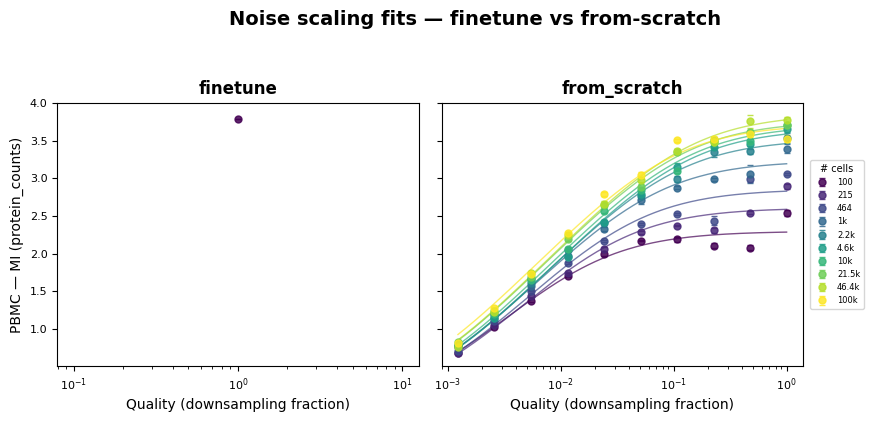

In [9]:
def plot_with_fits(df, df_fits, title='Noise scaling fits — finetune vs from-scratch'):
    sources = [s for s in ['finetune', 'from_scratch'] if s in df['source'].unique()]
    n_cols = len(sources)
    fig, axes = plt.subplots(1, n_cols,
                             figsize=(4 * n_cols + 1.6, 3.5 + 0.8),
                             squeeze=False, sharey=True)
    cmap = plt.cm.viridis
    sizes_all = sorted(df['size'].unique())
    norm = mcolors.LogNorm(vmin=min(sizes_all), vmax=max(sizes_all))

    for j, src in enumerate(sources):
        ax = axes[0, j]
        sub = df[df['source'] == src]
        sub_fits = df_fits[df_fits['source'] == src]
        for sz in sorted(sub['size'].unique()):
            color = cmap(norm(sz))
            agg = sub[sub['size'] == sz].groupby('quality')['mi_value'].agg(
                ['mean', 'std', 'count']).reset_index().sort_values('quality')
            agg['sem'] = (agg['std'] / np.sqrt(agg['count'])).fillna(0)
            ax.errorbar(agg['quality'], agg['mean'], yerr=agg['sem'],
                        marker='o', markersize=MARKER_SIZE, linewidth=0, capsize=2,
                        color=color, alpha=0.85, label=_fmt_size(sz))
            f = sub_fits[sub_fits['size'] == sz]
            if not f.empty and f['success'].iloc[0]:
                u = np.logspace(np.log10(agg['quality'].min()),
                                np.log10(agg['quality'].max()), 200)
                ax.plot(u, info_scaling(u, f['u_bar'].iloc[0], f['I_max'].iloc[0]),
                        color=color, lw=1.0, alpha=0.7)
        ax.set_xscale('log')
        ax.set_xlabel('Quality (downsampling fraction)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'PBMC — MI ({SIGNAL})', fontsize=10)
        ax.set_title(src, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=8)

    last_ax = axes[0, -1]
    handles, labels = last_ax.get_legend_handles_labels()
    if handles:
        last_ax.legend(handles, labels, title='# cells', fontsize=6,
                       title_fontsize=7, loc='center left',
                       bbox_to_anchor=(1.02, 0.5), borderaxespad=0,
                       frameon=True, framealpha=0.8)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    fig.tight_layout(rect=[0, 0.01, 0.92, 0.93])
    return fig

if not df_fits.empty:
    _ = plot_with_fits(df, df_fits)
    plt.show()